# Evaluacija — poređenje sa baseline metodom i BSDS500

Cilj ove sveske je da objektivnije proceni koliko spektralno klasterovanje zaista doprinosi kvalitetu segmentacije, kroz dva pristupa:

1. **Poređenje sa baseline metodom** — K-means primenjen direktno na karakteristike superpiksela (boja + pozicija), bez konstrukcije grafa i Laplasijana. Ovo pokazuje da li graf-bazirani pristup zaista donosi prednost u odnosu na jednostavnije klasterovanje.
2. **Kvantitativna evaluacija na BSDS500** — poređenje segmentacije sa ground-truth anotacijama, korišćenjem Adjusted Rand Index (ARI) metrike.

Tok sveske:
1. Baseline metoda (K-means bez grafovske strukture)
2. Vizuelno poređenje: spektralno klasterovanje vs baseline
3. BSDS500 — priprema podataka
4. Kvantitativna evaluacija (ARI), uz variranje k
5. Konačni zaključak

In [6]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.segmentation import slic

from image_utils import (
    compute_superpixel_features,
    build_image_similarity_matrix
)

from spectral import spectral_clustering_from_similarity
from segmentation import baseline_kmeans_segmentation
from evaluation import evaluate_segmentation, evaluate_bsds_images
from visualization import compare_segmentations, plot_segmentation_results, plot_ari_comparison

## 1. Baseline metoda — K-means bez grafovske strukture

Baseline pristup koristi iste karakteristike superpiksela (prosečna boja i pozicija) kao i spektralno klasterovanje, ali ih klasteruje direktno, standardnim K-means algoritmom — bez konstrukcije grafa sličnosti, Laplasijana, ili sopstvene-dekompozicije. Poređenje ova dva pristupa pokazuje da li graf-bazirana reprezentacija zaista doprinosi kvalitetu segmentacije, ili je razlika zanemarljiva.

## 2. Vizuelno poređenje: spektralno klasterovanje vs baseline

Upoređujemo oba pristupa na istoj slici (cvet na uniformnoj pozadini), korišćenjem istog parametra k.

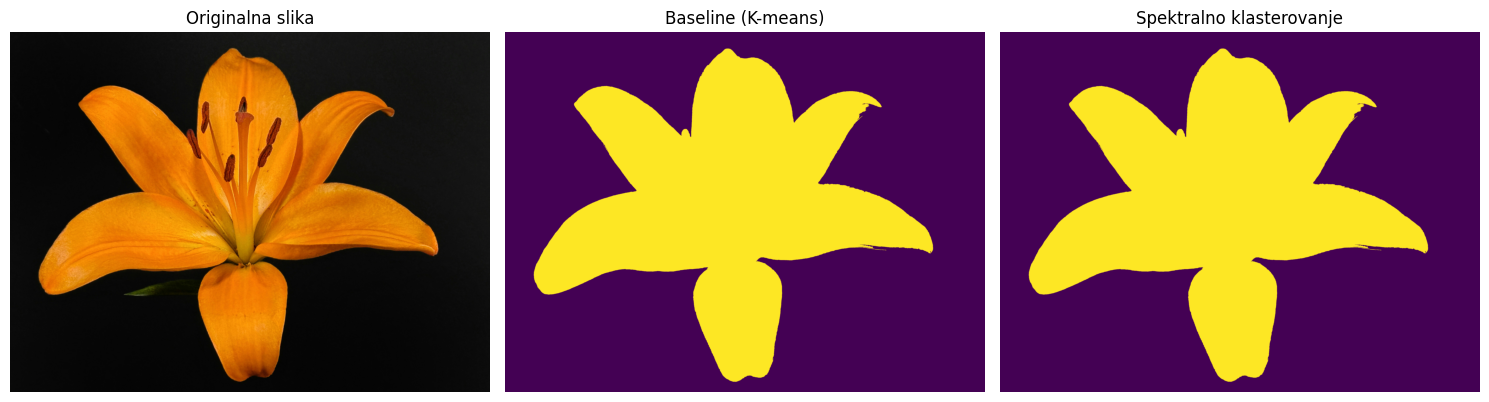

In [7]:
compare_segmentations(
    '../data/sample_images/yellow_lilly.jpg',
    k=2
)

**Zapažanje:** Na ovoj slici, baseline metoda daje rezultat praktično identičan spektralnom 
klasterovanju — oba pristupa čisto i tačno izdvajaju cvet od pozadine. Ovo je očekivano s obzirom 
na prirodu slike: uniformna pozadina i jasno kontrastan objekat čine da je granica između klastera 
jednostavna (skoro linearno razdvojiva), pa dodatna 
grafovska struktura ne donosi značajnu prednost.

### 2.1 Poređenje na slici gde spektralno klasterovanje ima teškoće

Ponavljamo poređenje na slici sa poljima cveća, gde je spektralno klasterovanje ranije pokazalo tendenciju ka deljenju po poziciji umesto po sadržaju.

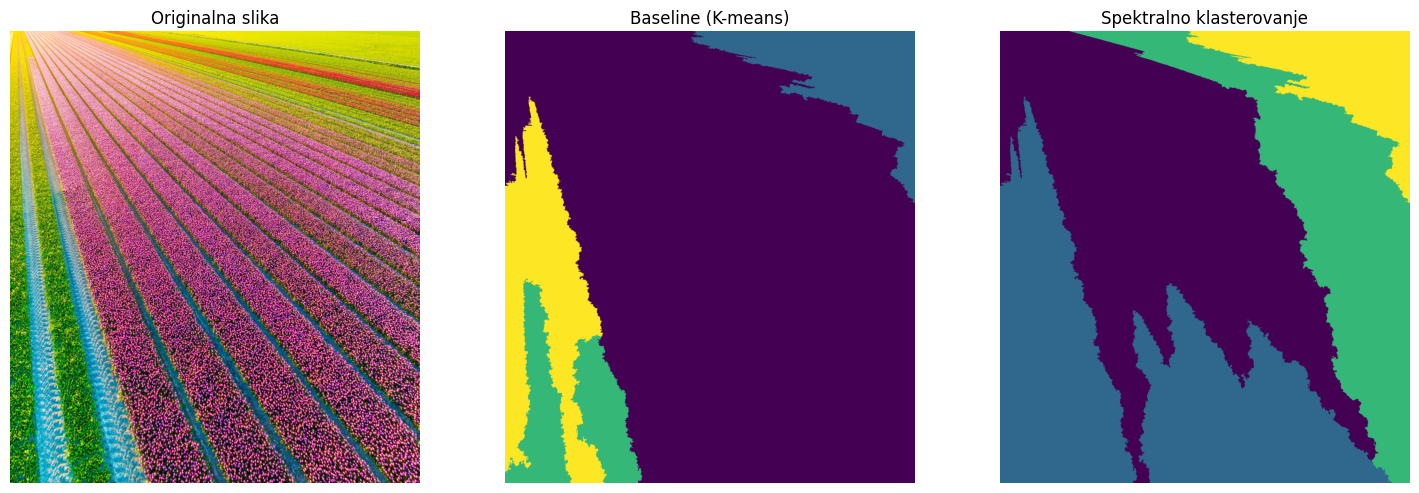

In [8]:
compare_segmentations(
    '../data/sample_images/fields.jfif',
    k=4
)

**Zapažanje:** Baseline metoda ovde pravi suštinski istu grešku kao spektralno klasterovanje — 
obe metode dele sliku pretežno dijagonalno/prostorno, umesto da prate stvarne redove cveća. Ovo 
pokazuje da problem nije u samom algoritmu klasterovanja, već u izboru karakteristika (boja + 
pozicija), koje ne uspevaju da uhvate periodičnu, teksturalnu strukturu ove slike.

## 3. BSDS500 — priprema podataka

[Berkeley Segmentation Dataset (BSDS500)](https://www.kaggle.com/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500) sadrži slike sa ručno beleženim ground-truth segmentacijama (više anotatora po slici), što omogućava kvantitativnu evaluaciju.

Tri slike i odgovarajući ground-truth `.mat` fajlovi preuzeti su iz BSDS500 dataseta i sačuvani u `data/bsds500/images/` i `data/bsds500/ground_truth/`.

## 4. Kvantitativna evaluacija (ARI)

Za poređenje dobijene segmentacije sa ground-truth segmentacijom koristimo **Adjusted Rand Index (ARI)**. Ova metrika meri stepen slaganja između dve podele skupa na klastere, nezavisno od konkretnih oznaka dodeljenih klasterima. Vrednost 1 označava savršeno poklapanje, dok vrednost bliska 0 ukazuje na slaganje približno nivou koji bi se mogao očekivati slučajnim pogađanjem.

Testiramo sa tri vrednosti k (2, 3, 4), pošto ground-truth segmentacije za različite slike sadrže različit broj regiona — fiksna vrednost k ne mora odgovarati svakoj slici podjednako dobro.

In [9]:
bsds_image_names = ['107072', '108004', '147080']
k_values = [2, 3, 4]

all_results, ari_table = evaluate_bsds_images(
    bsds_image_names,
    k_values
)

ari_table.style.format({
    'ARI - Spektralno': '{:.3f}',
    'ARI - Baseline': '{:.3f}'
})

,Slika,k,ARI - Spektralno,ARI - Baseline
0,107072,2,0.334,0.362
1,108004,2,-0.003,-0.003
2,147080,2,0.252,0.263
3,107072,3,0.379,0.484
4,108004,3,0.040,-0.068
5,147080,3,0.385,0.425
6,107072,4,0.198,0.429
7,108004,4,-0.013,0.009
8,147080,4,0.388,0.424


**Zapažanje:** Testiranje sa k=2, 3 i 4 na tri BSDS500 slike pokazuje da baseline metoda dostiže 
jednak ili veći ARI od spektralnog klasterovanja u 8 od 9 kombinacija slika i k vrednosti. Jedini 
izuzetak je slika sa tigrom pri k=3, gde spektralno klasterovanje blago nadmašuje baseline (0.040 
vs -0.068) — oba rezultata su ipak blizu nule, što ukazuje na slab kvalitet segmentacije kod oba 
metoda na toj slici. Generalno, k=3 daje najbolje rezultate za slike sa slonovima i decom, 
potvrđujući da tačan izbor k (usklađen sa stvarnim brojem regiona u ground truth-u) značajno 
utiče na kvalitet segmentacije kod oba metoda.

### 4.1 Vizuelni prikaz rezultata (k = 3)

Prikazujemo grid rezultata za k=3, koje je dalo najbolji generalni rezultat u tabeli iznad.

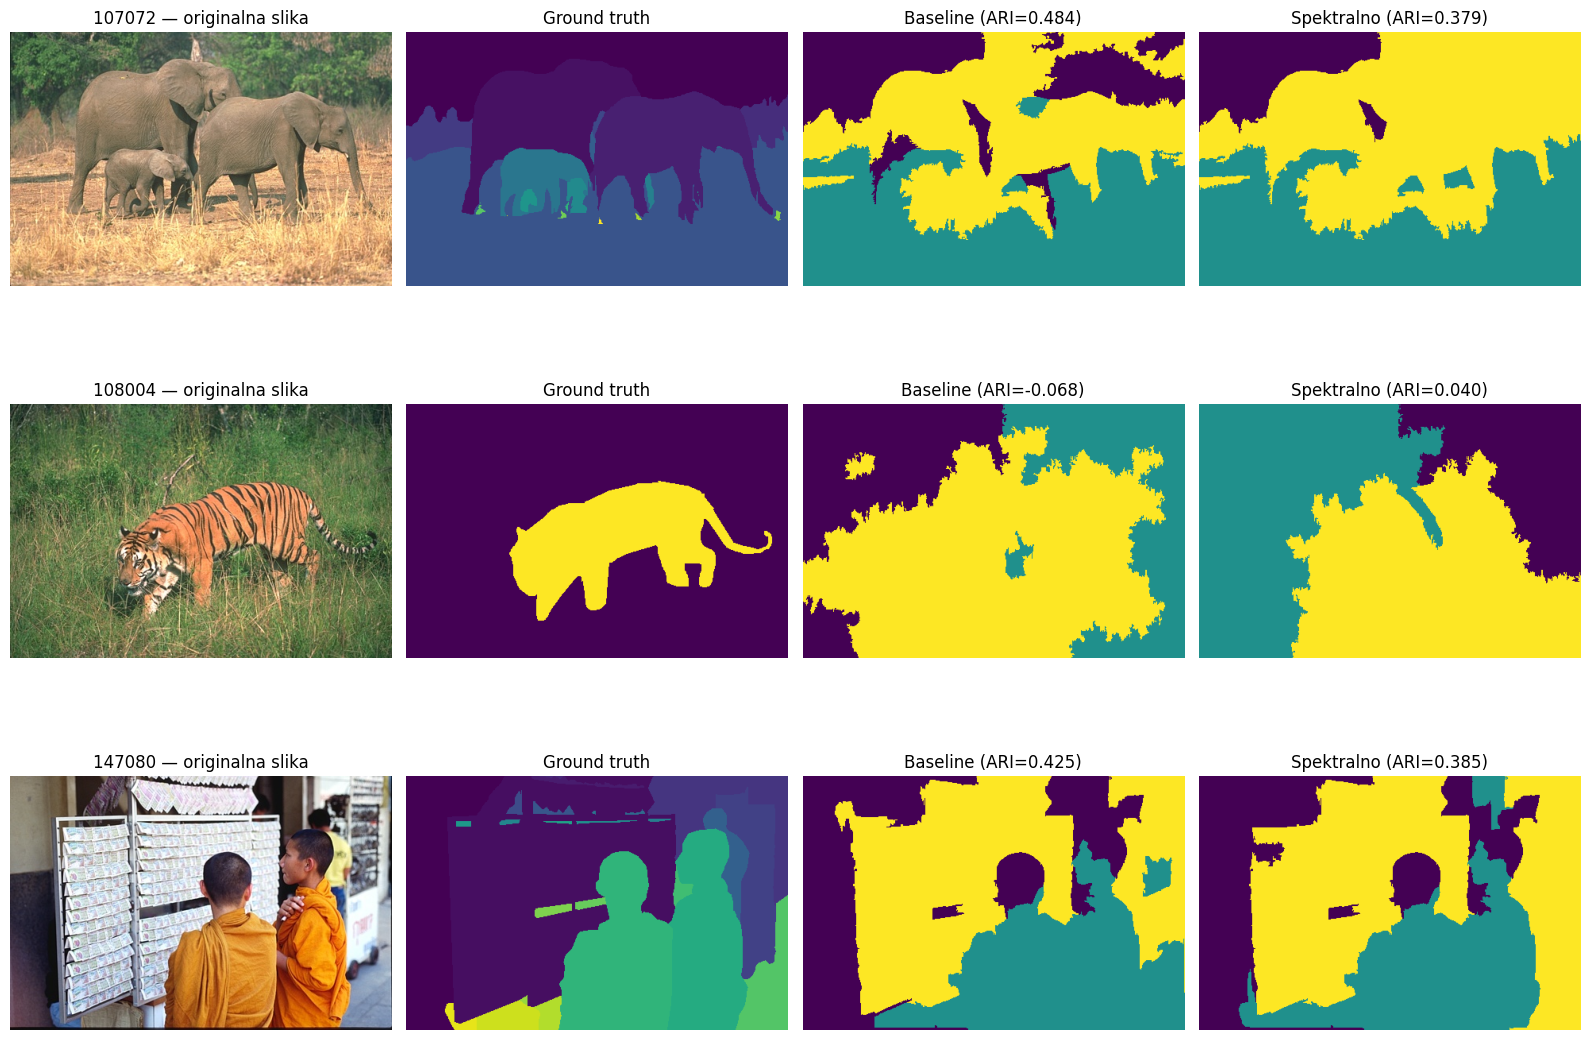

In [10]:
plot_segmentation_results(all_results, k = 3)

**Zapažanje:** Vizuelnim pregledom rezultata za k=3 uočava se da oba metoda hvataju grubu siluetu 
objekta od interesa, ali sa nepreciznim, "izlomljenim" granicama koje ne prate stvarne konture 
(slonovi, deca) — posledica toga što se segmentacija oslanja samo na boju i poziciju superpiksela, 
bez informacije o obliku ili teksturi. Kod slike sa tigrom, oba metoda potpuno promašuju ground 
truth — umesto siluete tigra, dobija se gruba podela cele slike na tri velika prostorna bloka, što 
objašnjava zašto su ARI vrednosti za tu sliku blizu nule kod oba pristupa. Baseline i spektralno klasterovanje daju vrlo slične podele na sve tri slike — razlika između 
dva pristupa je ovde minimalna, što potvrđuje i brojčano poređenje ARI vrednosti.

### Grafičko poređenje ARI po metodi (k = 3)

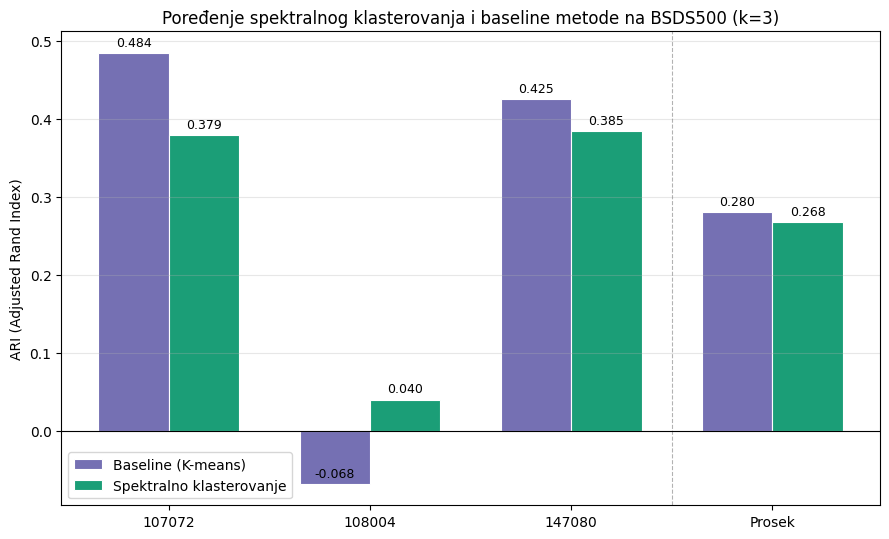

In [11]:
plot_ari_comparison(all_results, k=3)

## Konačni zaključak

Poređenje sa baseline metodom (K-means bez grafovske strukture), i vizuelno i kroz BSDS500 
evaluaciju, pokazuje da spektralno klasterovanje ne daje dosledno bolje rezultate od jednostavnijeg 
pristupa na realnim fotografijama — u većini testiranih slučajeva rezultati su uporedivi ili 
baseline neznatno bolji. Pokazalo se i da je k jedan od najosetljivijih hiperparametara, čiji 
optimalan izbor zavisi od stvarnog broja regiona u slici.

Ovakav rezultat je u kontrastu sa sintetičkim make_moons podacima, na kojima je prednost spektralnog klasterovanja u prepoznavanju nekonveksnih struktura jasno pokazana. To ukazuje na činjenicu da se teorijske prednosti neke metode ne prenose nužno na svaki tip podataka. U slučaju realnih fotografija, struktura podataka u prostoru karakteristika zasnovanom na boji i poziciji može biti jednostavnija nego kod veštački konstruisanih primera, zbog čega složenija metoda ne mora uvek da daje bolje rezultate. Izbor između metoda zato treba zasnivati na eksperimentalnoj evaluaciji, a ne na pretpostavci da će spektralno klasterovanje nužno nadmašiti K-means

**Moguće poboljšanje:** automatski izbor k na osnovu strukture slike (npr. eigengap heuristika, Von Luxburg 
2007); proširenje karakteristika superpiksela teksturom, koje bi moglo doprineti kako boljoj 
segmentaciji repetitivnih struktura (primer slike sa poljima), kao i boljem razlikovanju objekata sličnih pozadini 
po boji (primer slike sa papagajem).